# Saliency Maps

Saliency maps are gradient-based attribution methods that highlight which input features most influence a model's prediction. They provide fine-grained, spatial explanations by tracing gradients from the output back to the input.

In this study, the saliency maps for 10 m wind speed forecasts are computed using three techniques:
- Vanilla Gradients: Raw gradients of the output with respect to the input.

- Gradient × Input: Element-wise product of the input and its gradient, amplifying regions where the input is both high and influential.

- Integrated Gradients: A path-based method that accumulates gradients along a linear interpolation between a baseline (here, climatology) and the input.

Gradients for the wind speed are calculated using polar coordinates.

In [11]:
import xarray as xr

from pkg.saliency_maps.compute_gradient import run_forecast_with_gradients, run_forecast_with_integrated_gradients
from pkg.plots.saliency_plots import plot_surface_saliency, plot_atmospheric_saliency
from pkg.plots.plot_variable import plot_variable

In [12]:
input_path = "../data/graphcast_small/graphcast_small_zeynep_input/graphcast_ready_input_graphcast_small_zeynep_input.nc"
climatology_path = "../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"

input = xr.open_dataset(input_path).load()
climatology = xr.open_dataset(climatology_path)

## Run Forecast

### Vanilla and Grad_x_Input Gradient

In [ ]:
run_forecast_with_gradients(
    model_name="graphcast_small",
    input_data_or_path=input,
    output_name="zeynep_wind_grad",
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6,
    upload_to_gcs=False
)

📦 Using checkpoint: graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/.venv/lib/python3.12/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_inputs = inputs.dims['time']


### Integrated Gradients

In [ ]:
run_forecast_with_integrated_gradients(
    model_name="graphcast_small",
    input_data_or_path=input,
    output_name="zeynep_wind_grad",
    baseline=climatology,
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6,
    m_steps=1,
    upload_to_gcs=False
)

## Plot Results

In [13]:
saliency_path = "../data/saliency_maps/zeynep_wind_grad_saliency.nc"
saliency_path_grad_x_input = "../data/saliency_maps/zeynep_wind_grad_grad_x_input.nc"
saliency_path_integrated_gradients = "../data/saliency_maps/zeynep_wind_grad_integrated.nc"

sal_ds = xr.open_dataset(saliency_path)
sal_ds_grad_x_input = xr.open_dataset(saliency_path_grad_x_input)
sal_ds_integrated_gradients = xr.open_dataset(saliency_path_integrated_gradients)

### Surface Saliency

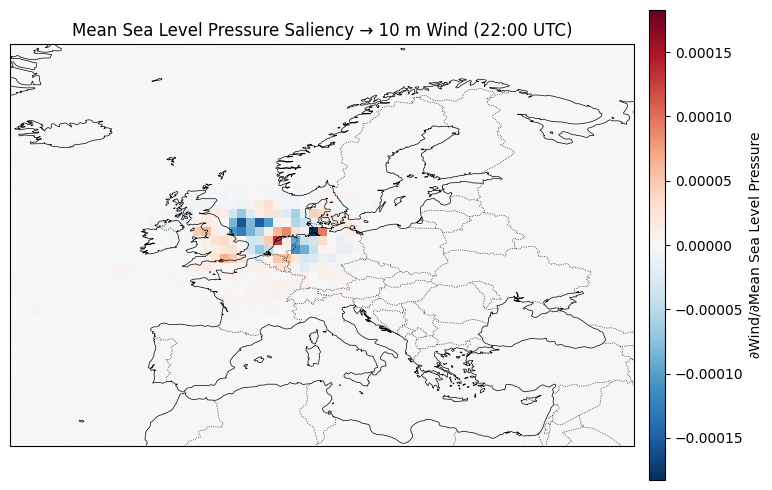

(<Figure size 1000x600 with 2 Axes>,
 <GeoAxes: title={'center': 'Zeynep (18th February 2018)'}>)

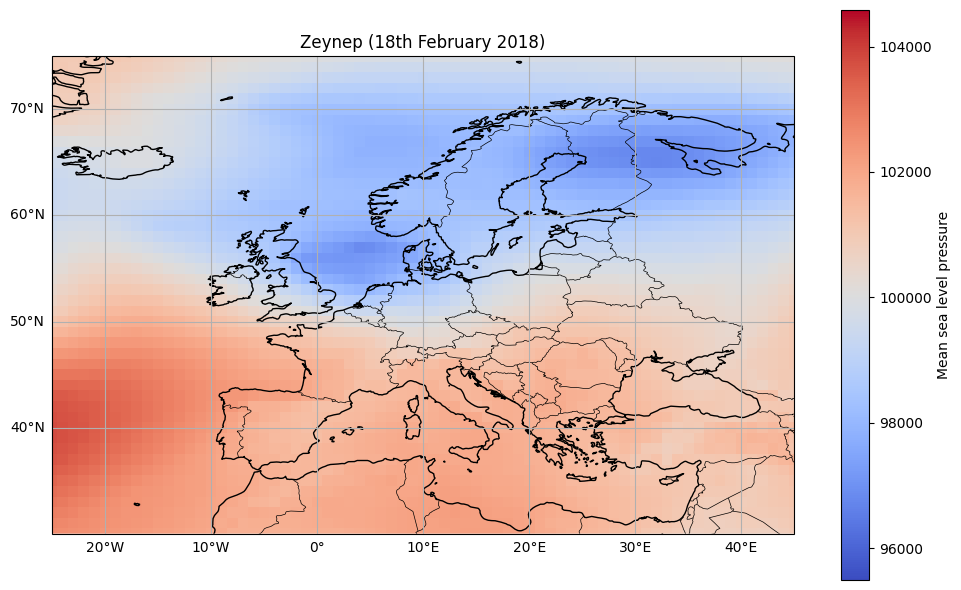

In [14]:
# saliency data: sal_ds (vanilla gradients), sal_ds_grad_x_input, sal_ds_integrated_gradients
saliency_data = sal_ds

# surface variables: "2m_temperature", "10m_u_component_of_wind", "10m_v_component_of_wind", 
# "total_precipitation_6hr", "mean_sea_level_pressure"
surf_var = "mean_sea_level_pressure"

# time_index: 0 for 10:00 UTC, 1 for 16:00 UTC
time = 1  # Second to last time step 

plot_surface_saliency(saliency_data, input, surf_var, time_index=time)

plot_variable(
    input,
    time=time,
    level=None,
    var_name=surf_var,
    title="Zeynep (18th February 2018)",
)

### Atmospheric Saliency

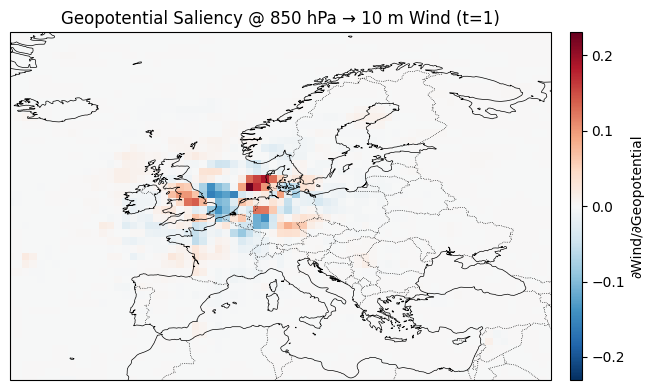

(<Figure size 1000x600 with 2 Axes>,
 <GeoAxes: title={'center': 'Zeynep (18th February 2018)'}>)

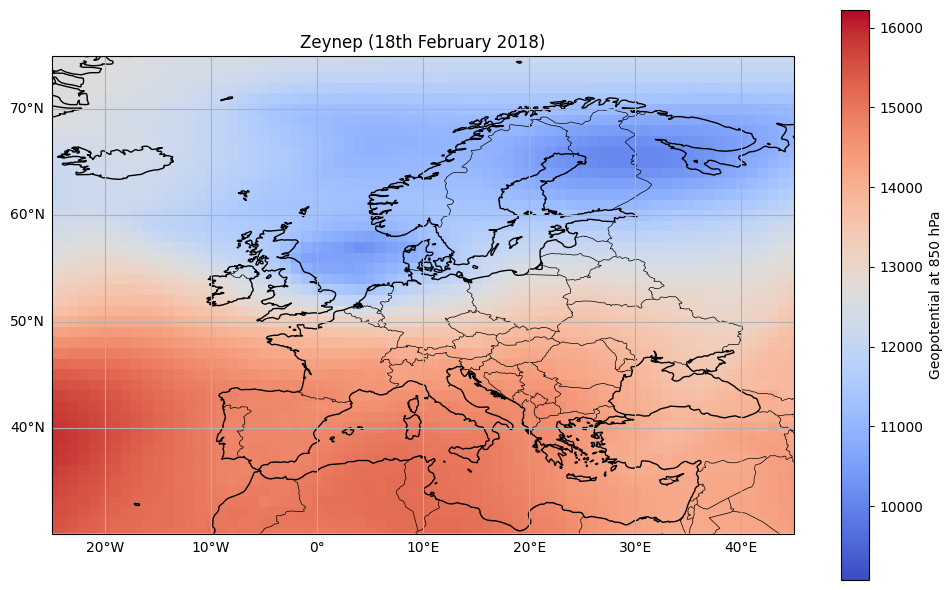

In [15]:
# saliency data: sal_ds (vanilla gradients), sal_ds_grad_x_input, sal_ds_integrated_gradients
saliency_data = sal_ds_integrated_gradients

# atmospheric variables: geopotential, temperature, specific_humidity, 
# u_component_of_wind, v_component_of_wind, vertical_velocity
varname = "geopotential"

# level
level = 850

# time_index: 0 for 10:00 UTC, 1 for 16:00 UTC
time = 1

# extent: [lon_min, lon_max, lat_min, lat_max]
extent=[-25, 45, 30, 75]


plot_atmospheric_saliency(
    sal_ds=saliency_data,
    input_ds=input,
    varname=varname,
    target_level=level,
    time_index=time,
    batch_index=0,
    extent=extent
)

plot_variable(
    input,
    time=time,
    level=level,
    var_name=varname,
    extent=extent,
    title="Zeynep (18th February 2018)",
)

# Wind Speed


In [16]:
# Load wind speed

# Vanilla
saliency_path_surface_wind_speed = "../data/saliency_maps/zeynep_wind_grad_wind_speed_saliency.nc"
saliency_path_levels_wind_speed = "../data/saliency_maps/zeynep_wind_grad_wind_speed_levels_saliency.nc"

sal_ds_surface_wind_speed = xr.open_dataset(saliency_path_surface_wind_speed)
sal_ds_levels_wind_speed = xr.open_dataset(saliency_path_levels_wind_speed)

# Grad x Input
saliency_path_grad_x_input_surface_wind_speed = "../data/saliency_maps/zeynep_wind_grad_wind_speed_grad_x_input.nc"
saliency_path_grad_x_input_levels_wind_speed = "../data/saliency_maps/zeynep_wind_grad_wind_speed_levels_grad_x_input.nc"

sal_ds_grad_x_input_surface_wind_speed = xr.open_dataset(saliency_path_grad_x_input_surface_wind_speed)
sal_ds_grad_x_input_levels_wind_speed = xr.open_dataset(saliency_path_grad_x_input_levels_wind_speed)


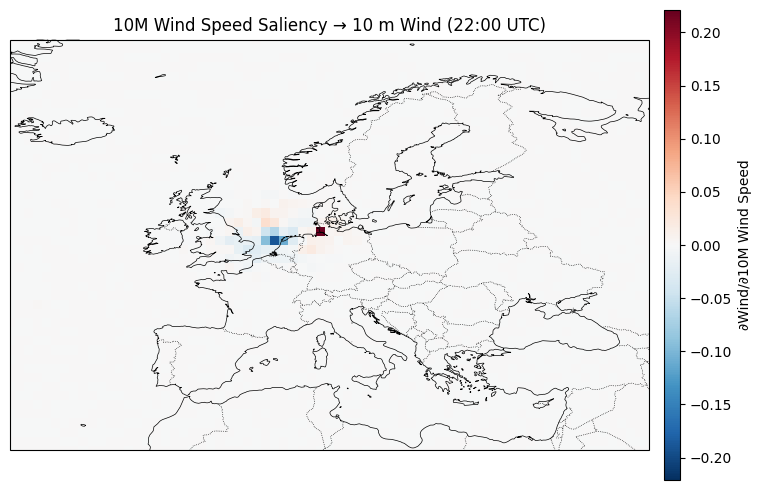

(<Figure size 1000x600 with 2 Axes>,
 <GeoAxes: title={'center': 'Zeynep (18th February 2018)'}>)

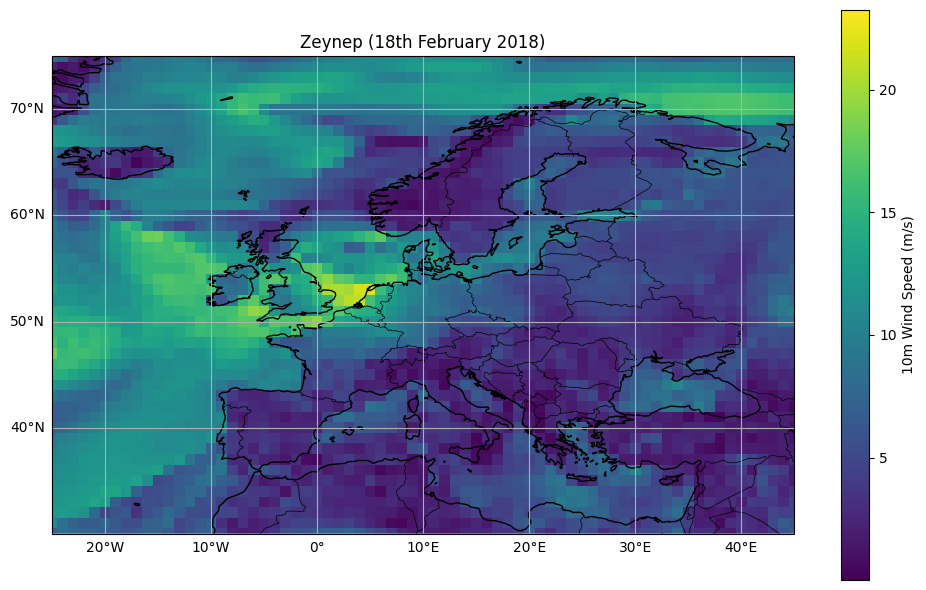

In [17]:
# saliency data: sal_ds_surface_wind_speed (vanilla gradients), sal_ds_grad_x_input_surface_wind_speed, sal_ds_integrated_gradients
saliency_data_surface_wind_speed = sal_ds_grad_x_input_surface_wind_speed

surf_var = "10m_wind_speed"

# time_index: 0 for 10:00 UTC, 1 for 16:00 UTC
time = 1  # Second to last time step

plot_surface_saliency(saliency_data_surface_wind_speed, input, surf_var, time_index=time)

plot_variable(
    input,
    time=time,
    level=None,
    var_name=surf_var,
    title="Zeynep (18th February 2018)",
)

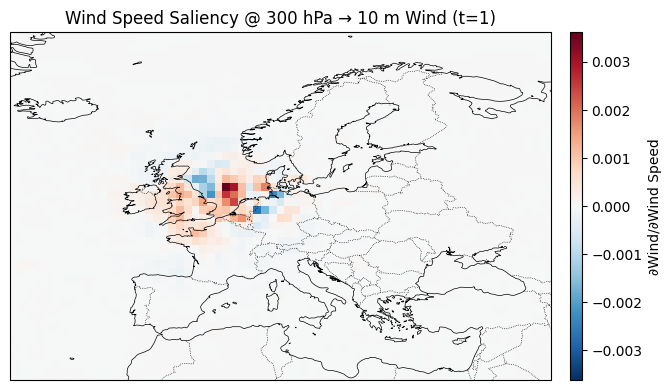

(<Figure size 1000x600 with 2 Axes>,
 <GeoAxes: title={'center': 'Zeynep (18th February 2018)'}>)

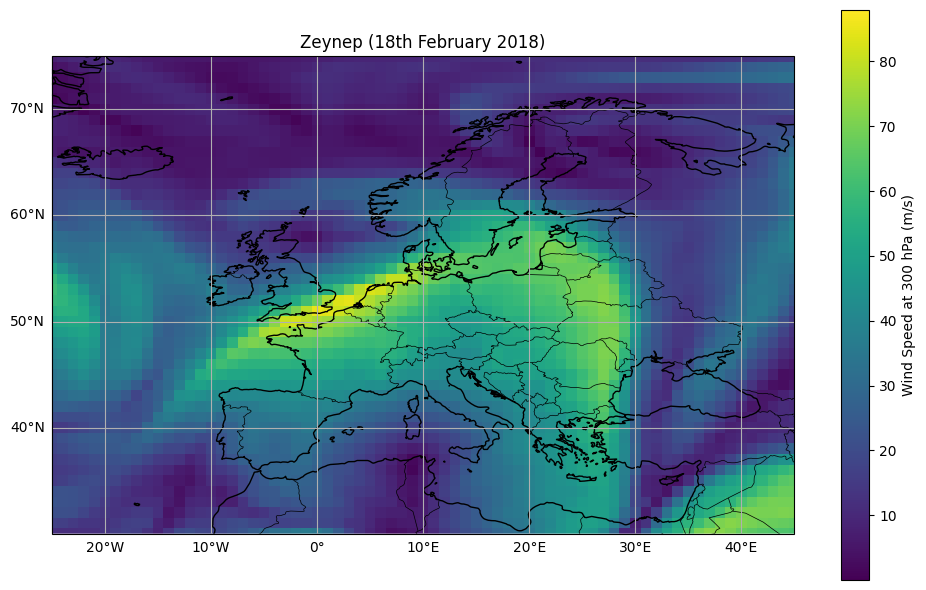

In [18]:
# saliency data: sal_ds_levels_wind_speed (vanilla gradients), sal_ds_grad_x_input_levels_wind_speed, sal_ds_integrated_gradients_levels_wind_speed
saliency_data_levels_wind_speed = sal_ds_levels_wind_speed

varname = "wind_speed"

# level
level = 300

# time_index: 0 for 10:00 UTC, 1 for 16:00 UTC
time = 1

# extent: [lon_min, lon_max, lat_min, lat_max]
extent=[-25, 45, 30, 75]


plot_atmospheric_saliency(
    sal_ds=saliency_data_levels_wind_speed,
    input_ds=input,
    varname=varname,
    target_level=level,
    time_index=time,
    batch_index=0,
    extent=extent
)

plot_variable(
    input,
    time=time,
    level=level,
    var_name=varname,
    extent=extent,
    title="Zeynep (18th February 2018)",
)